In [36]:
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler, MinMaxScaler


pd.set_option('display.max_columns', None)

df = pd.read_csv('final_gold.csv')

df['time'] = pd.to_datetime(df['time'])
df['hora'] = df['time'].dt.hour
df['part_of_day'] = df['hora'].apply(lambda h: (
    0 if h < 6 else #Madrugada = 0
    3 if h < 12 else #Mañana = 3
    2 if h < 18 else  #Tarde = 2
    1 #Noche = 1
))

df['mes'] = df['time'].dt.month
df['season'] = df['hora'].apply(lambda h: (
    0 if h in [12,1,2] else #Invierno = 0
    1 if h in [3,4,5] else #Primavera = 1
    2 if h in [6,7,8] else #Verano = 2
    3 #Otoño = 3
))

df['hora_sin'] = np.sin(2 * np.pi * df['hora'] / 23)
df['hora_cos'] = np.cos(2 * np.pi * df['hora'] / 23)

df["dia_semana"] = df["time"].dt.dayofweek     # Día de la semana (0=lunes)
# Codificación one-hot para dia_semana (ahora solo contiene 0 a 4)
df = pd.get_dummies(df, columns=['dia_semana'], prefix='dia', drop_first=True)



X_df = df.drop(columns=["time","temperatura_calefaccion_y",'sensor.sensor_temperatura_2_humidity', 'sensor.sensor_temperatura_2_pressure', 'sensor.sensor_temperatura_2_temperature', 'sensor.sensor_temperatura_3_humidity', 'sensor.sensor_temperatura_3_pressure', 'sensor.sensor_temperatura_3_temperature'])
y_df = df["temperatura_calefaccion_y"]



# Separar datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X_df, y_df, test_size=0.2, random_state=42)

model = LinearRegression()  
model.fit(X_train, y_train)

# Predicciones
y_pred = model.predict(X_test)

# Métricas
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Resultados
print("R²:", r2)
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)

# probar tasas de aprendizaje, funciones activacion y num neuronas

df.to_csv('entrenamiento_neuronal_calefaccion.csv', index=False)

X_df


R²: 0.9228992506146165
MAE: 0.5258244571863165
MSE: 0.43403962779833866
RMSE: 0.658816839340297


,sensor.sensor_temperatura_1_humidity,sensor.sensor_temperatura_1_pressure,sensor.sensor_temperatura_1_temperature,sensor_puerta_1 Puerta,suma_ventanas_arriba,suma_ventanas_abajo,azimuth_mean,elevacion_sol,temperatura_exterior,porcentaje_nubes,hora,part_of_day,mes,season,hora_sin,hora_cos,dia_1,dia_2,dia_3,dia_4,dia_5,dia_6
0,46.30,1014.6,19.74,0.0,0.0,0.0,285.41,-53.48,12.5,100.0,21,1,12,3,-5.195840e-01,0.854419,True,False,False,False,False,False
1,45.78,1014.6,19.51,0.0,0.0,0.0,303.03,-64.02,12.0,100.0,22,1,12,3,-2.697968e-01,0.962917,True,False,False,False,False,False
2,45.45,1014.2,19.24,0.0,0.0,0.0,250.84,-72.16,11.4,100.0,23,1,12,3,-2.449294e-16,1.000000,True,False,False,False,False,False
3,45.30,1014.4,19.09,0.0,0.0,0.0,29.55,-71.20,11.2,39.0,0,0,12,3,0.000000e+00,1.000000,False,True,False,False,False,False
4,45.25,1014.4,18.86,0.0,0.0,0.0,59.16,-63.06,10.6,32.0,1,0,12,0,2.697968e-01,0.962917,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2492,47.17,1011.5,21.36,3600.0,0.0,0.0,273.44,-1.18,15.5,87.0,18,1,3,3,-9.790841e-01,0.203456,False,False,False,False,False,False
2493,47.73,1012.2,21.40,2366.0,0.0,0.0,283.89,-13.52,14.7,56.0,19,1,3,3,-8.878852e-01,0.460065,False,False,False,False,False,False
2494,48.80,1013.2,20.71,0.0,0.0,0.0,295.64,-25.12,13.5,33.0,20,1,3,3,-7.308360e-01,0.682553,False,False,False,False,False,False
2495,49.68,1013.5,20.17,0.0,0.0,0.0,308.84,-34.89,13.1,41.0,21,1,3,3,-5.195840e-01,0.854419,False,False,False,False,False,False


# Red neuronal

Epoch 1/50


/home/pablo/miniconda3/envs/tf-wsl-ia/lib/python3.9/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 98ms/step - accuracy: 0.4325 - loss: 5.5872 - precision_7: 0.4974 - recall_7: 0.2525 - val_accuracy: 0.9386 - val_loss: 0.2968 - val_precision_7: 0.9103 - val_recall_7: 1.0000
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8178 - loss: 0.4403 - precision_7: 0.8213 - recall_7: 0.9060 - val_accuracy: 0.9298 - val_loss: 0.1921 - val_precision_7: 0.8987 - val_recall_7: 1.0000
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8447 - loss: 0.3710 - precision_7: 0.8867 - recall_7: 0.8733 - val_accuracy: 0.9211 - val_loss: 0.2063 - val_precision_7: 1.0000 - val_recall_7: 0.8732
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8853 - loss: 0.2868 - precision_7: 0.9194 - recall_7: 0.8981 - val_accuracy: 0.9474 - val_loss: 0.1355 - val_precision_7: 0.9710 - val_recall_7: 0.9437
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8901 - loss: 0.2983 - precision_7: 0.9092 - recall_7: 0.9206 - val_accuracy: 0.938

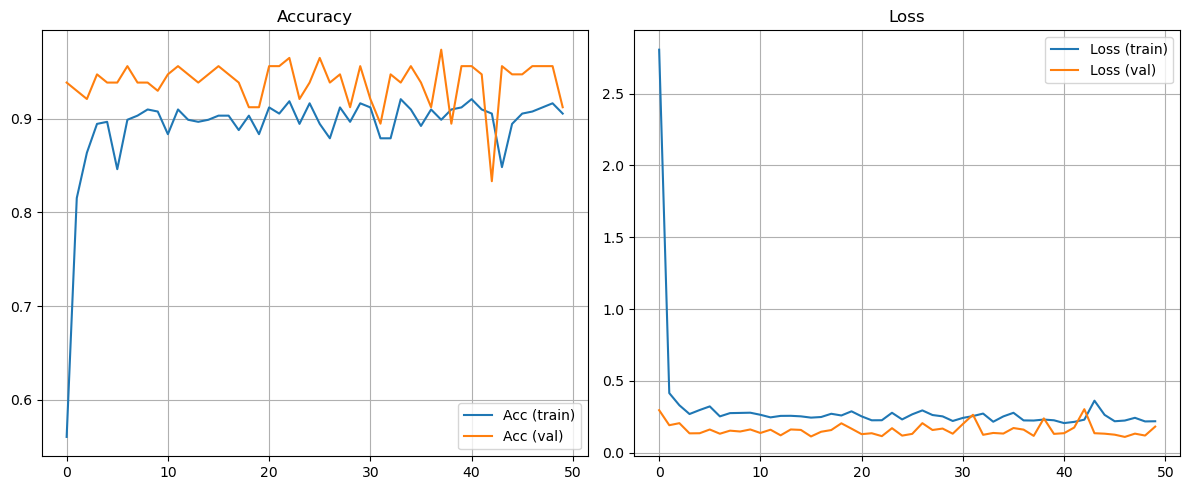

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Accuracy: 0.9122807017543859
Precision: 0.8765432098765432
Recall: 1.0


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Load and prepare data
data = load_breast_cancer()
X = data.data
y = data.target

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create the model - fixing the architecture
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),  # Removed redundant input_shape
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')  # Changed to sigmoid for binary classification
])

# Compile with appropriate loss function
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',  # Changed to appropriate loss for binary classification
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

# Train the model
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test)
)

# Plot training metrics
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Acc (train)')
plt.plot(history.history['val_accuracy'], label='Acc (val)')
plt.legend()
plt.grid(True)
plt.title("Accuracy")

# Plot loss separately
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss (train)')
plt.plot(history.history['val_loss'], label='Loss (val)')
plt.legend()
plt.grid(True)
plt.title("Loss")

plt.tight_layout()
plt.show()